# Notebook 4: Irish Pandemic Data SIR Model Estimation
### Peter.Nolan@gmail.com
### https://github.com/dpnolan

## Introduction ##
SIR epidemic model estimation for the Irish pandemic data, in two datasets 
- S(t) is the number of people susceptible to becoming infected (no immunity)
- I(t) is the number of people currently infected (and infectious)
- R(t) is the number of recovered people(SIR assumes that they remain immune)
- alpha $\alpha$ is the constant rate of infectious contact between people often called transmission rate
- gamma $\gamma$ is the rate of recovery of infected individuals, 1 over the days to recovery
- $R_0$ derived from them

## Setup

uses kernel __pymc_env_1__ on PC

In [36]:
!conda list --export > requirements.txt

In [37]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import pandas as pd
import arviz as az
from pytensor import scan
import matplotlib.pyplot as plt
from datetime import datetime

## Data sources 

Estimation uses datasets Irish IEMAG data from O'Brien (2020) and data as at late 2023 from CIDR 
- Inputs for the Irish Epidemiology Modelling Advisory Group modelling https://github.com/obrienjoey/ireland_covid_modelling/tree/main/Input_data
- Paper\
https://assets.gov.ie/static/documents/a-population-level-seir-model-for-covid-19-scenarios-updated-technical-note.pdf
- Health Protection Surveillance Centre, Computerised Infectious Disease Reporting dataset\
https://covid-19.geohive.ie/datasets/d8eb52d56273413b84b0187a4e9117be_0/about


## Data Retrieval and Cleaning

### IEMAG dataset 

In [38]:
dataset='IEMAG'
df1 = pd.read_csv("case_data_IRL_20201111.csv") #IEMAG data for published model
df1

,Date,daycount
0,02/03/2020,1
1,03/03/2020,1
2,04/03/2020,3
3,05/03/2020,3
4,06/03/2020,5
...,...,...
249,06/11/2020,333
250,07/11/2020,534
251,08/11/2020,267
252,09/11/2020,270


In [39]:
df1 = df1.rename(columns={"daycount": "I"})

df1.set_index("Date",inplace=True) # set the date as index

df1.I=df1.I*1.0 # cast I 
df1['I']=df1['I'].astype('float64')

df1

,I
Date,
02/03/2020,1.0
03/03/2020,1.0
04/03/2020,3.0
05/03/2020,3.0
06/03/2020,5.0
...,...
06/11/2020,333.0
07/11/2020,534.0
08/11/2020,267.0


### CIDR dataset. Run this to replace the IEMAG

In [40]:
dataset2='CIDR'
df2 = pd.read_csv("CIDRcases.csv") #CIDR data published up to Nov 2023
df2

,Date,CovidCasesConfirmed,CIDRcases
0,02/03/2020,1,1.0
1,03/03/2020,2,1.0
2,04/03/2020,5,3.0
3,05/03/2020,8,3.0
4,06/03/2020,13,5.0
...,...,...,...
1347,10/11/2023,1724813,108.0
1348,11/11/2023,1724911,98.0
1349,12/11/2023,1724911,0.0
1350,13/11/2023,1724911,0.0


__CIDRcases__ contains the infections on that day, calculated up to 14 Nov 2023

In [41]:
df2 = df2.rename(columns={"CIDRcases": "I"})
df2.set_index("Date",inplace=True)
df2.I=df2.I.astype('float64')
df2

,CovidCasesConfirmed,I
Date,,
02/03/2020,1,1.0
03/03/2020,2,1.0
04/03/2020,5,3.0
05/03/2020,8,3.0
06/03/2020,13,5.0
...,...,...
10/11/2023,1724813,108.0
11/11/2023,1724911,98.0
12/11/2023,1724911,0.0


JHU data showed negative deaths, so it was set aside, discounting the probability of the government bringing the dead back to life

## Model Setup

In [42]:
# Define the Republic of Ireland population as 4.9 million, as the IEMAG model does
N=4900000.0
N

4900000.0

### Specify model time window as the full dataset 

In [43]:
infected=df1.I#[50:200]
#infected = infected.reset_index(drop=True)

n_days = len(infected)
times = np.arange(n_days)
t_0 = 0
I_begin = infected.iloc[0]
S_begin = N - infected.iloc[0]
new_I0 = pt.zeros_like(I_begin)
#creates a tensor filled with zeros that has the same shape and data type as x

In [44]:
infected

Date
02/03/2020      1.0
03/03/2020      1.0
04/03/2020      3.0
05/03/2020      3.0
06/03/2020      5.0
              ...  
06/11/2020    333.0
07/11/2020    534.0
08/11/2020    267.0
09/11/2020    270.0
10/11/2020    362.0
Name: I, Length: 254, dtype: float64

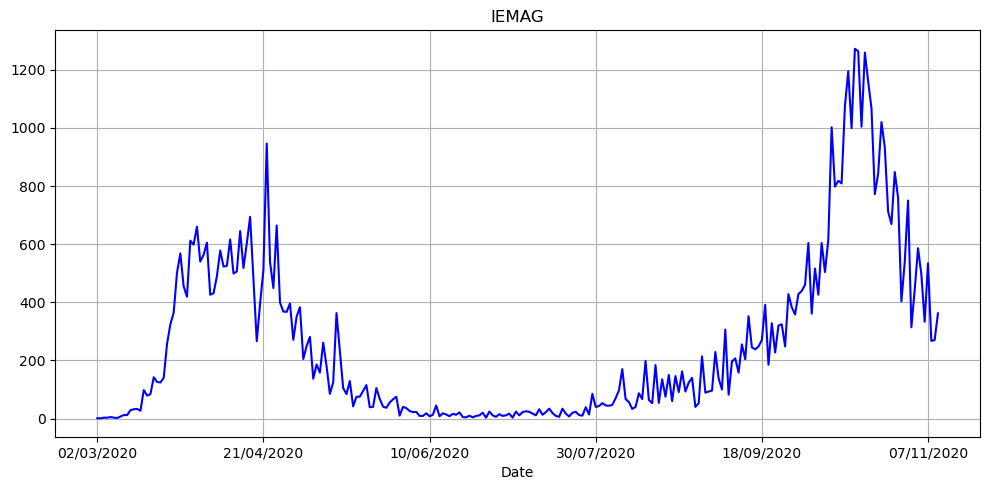

<Figure size 640x480 with 0 Axes>

In [45]:
df1.I.plot(figsize=(10, 5), title=dataset,color='blue')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('iemag1.png')

In [46]:
sum(df1.I<0)

0

## Define the model 

__si_func__ describes the ODE for the SIR model\
Marginalised estimate, ignoring R(t), which is not available, and calculating S(t) as N minus I(t)\
This function is based on: https://github.com/Priesemann-Group/covid19_inference/blob/master/covid19_inference/model/compartmental_models/SIR.py


In [47]:
def si_func(S_t, I_t, new_I0, beta, gamma, N):
    
    new_I_t = beta * S_t * I_t / N
    new_R_t = gamma * I_t 
    
    S_t = S_t - new_I_t 
    
    I_t = I_t + new_I_t - new_R_t   
    I_t = pt.clip(I_t, -1, N)  # for stability
    
    S_t = pt.clip(S_t, 0, N)
    
    return S_t, I_t, new_I_t


## Run the simulation using PyMC

* Priors: assumed distributions and their parameters for the beta and gamma
* Taken from Semenova et al. (2020) paper at https://mc-stan.org/learn-stan/case-studies/boarding_school_case_study.html
* Their code in Rstats and STAN at https://github.com/charlesm93/disease_transmission_workflow/blob/main/full_case_study_final.Rmd
  
* __pt.zeros__ Variables, S, I and R are initialised as tensors with zero values for the model variables
* __pt.subtensor.inc_subtensor__ PyTensor expression used to initialize the values of the first element of tensors S and I (for Susceptible and Infected)

* __scan__ Like in TensorFlow, we have initiated a graph, this then iterates through the ODE as defined in __si_func__



PyMC runs the Markov Chain Monte Carlo (MCMC), by default this is the No U-Turns (NUTS) algorithm 

In [48]:
with pm.Model() as mod:
    
    # Priors
    
    # Priors
    beta = pm.HalfNormal('beta',1) # match Semenova et al. priors
    #beta = pm.Wald('beta', 1, 1)
    #beta = pm.Wald('beta', 2, 1)
 
    gamma = pm.HalfNormal('gamma', 1) # match Semenova et al. priors
    #gamma = pm.Wald('gamma', 1, 1)
 
    
    # Variables
    S = pt.zeros(n_days)
    I = pt.zeros(n_days)
    R = pt.zeros(n_days)
    
    S = pt.subtensor.inc_subtensor(S[0], N - infected.iloc[0])
    I = pt.subtensor.inc_subtensor(I[0], infected.iloc[0])
    
    outputs, _ = scan(
        fn=si_func,
        outputs_info=[S_begin, I_begin, new_I0],
        non_sequences=[beta, gamma, N],
        n_steps=n_days
    )
    S_t, I_t, new_I_t = outputs
    
    S_t = pm.Deterministic("S_t", S_t)
    I_t = pm.Deterministic("I_t", I_t)
    #R_t = pm.Deterministic("R_t", R_t)
        
    # Likelihood
    phi_inv = pm.Exponential("phi_inv", 5)
    y=pm.NegativeBinomial("y", mu=I_t, alpha=phi_inv, observed=infected)
    
    R0 = pm.Deterministic("R0", beta/gamma)
    recovery_time = pm.Deterministic("recovery time", 1/gamma)
    
with mod:
    idata_log = pm.sample(1000, idata_kwargs={"log_likelihood": True},chains=4)
    idata_log.extend(pm.sample_posterior_predictive(idata_log))
    #idata = pm.sample_prior_predictive(draws=50)

summ = az.summary(idata_log, hdi_prob=0.9)

# Get current time formatted as yyyy-mm-dd hh:mm:ss
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(current_time)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, gamma, phi_inv]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 42 seconds.
Sampling: [y]


Output()

2025-07-14 20:24:39


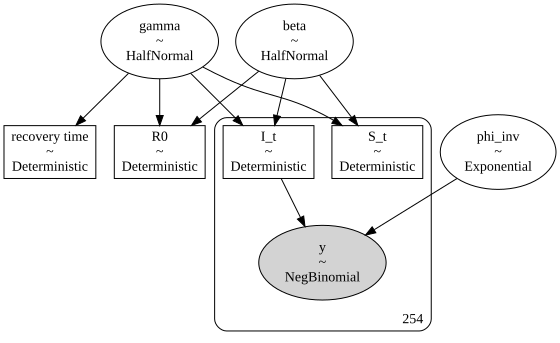

In [49]:
pm.model_to_graphviz(mod)

* Chain is one sequence of samples, by default 4 are run, but this can be changed manually above 
* Divergences suggest that the sampler had trouble traversing parts of the parameter space smoothly

In [50]:
az.summary(idata_log, var_names=["beta", "gamma", "R0", "recovery time"],hdi_prob=0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,0.298,0.027,0.256,0.336,0.001,0.001,1247.0,1500.0,1.01
gamma,0.060,0.004,0.053,0.067,0.000,0.000,1219.0,1334.0,1.00
R0,4.981,0.787,3.792,6.230,0.023,0.016,1174.0,1354.0,1.01
recovery time,16.642,1.178,14.642,18.487,0.034,0.024,1219.0,1334.0,1.00


In [51]:
idata_log

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

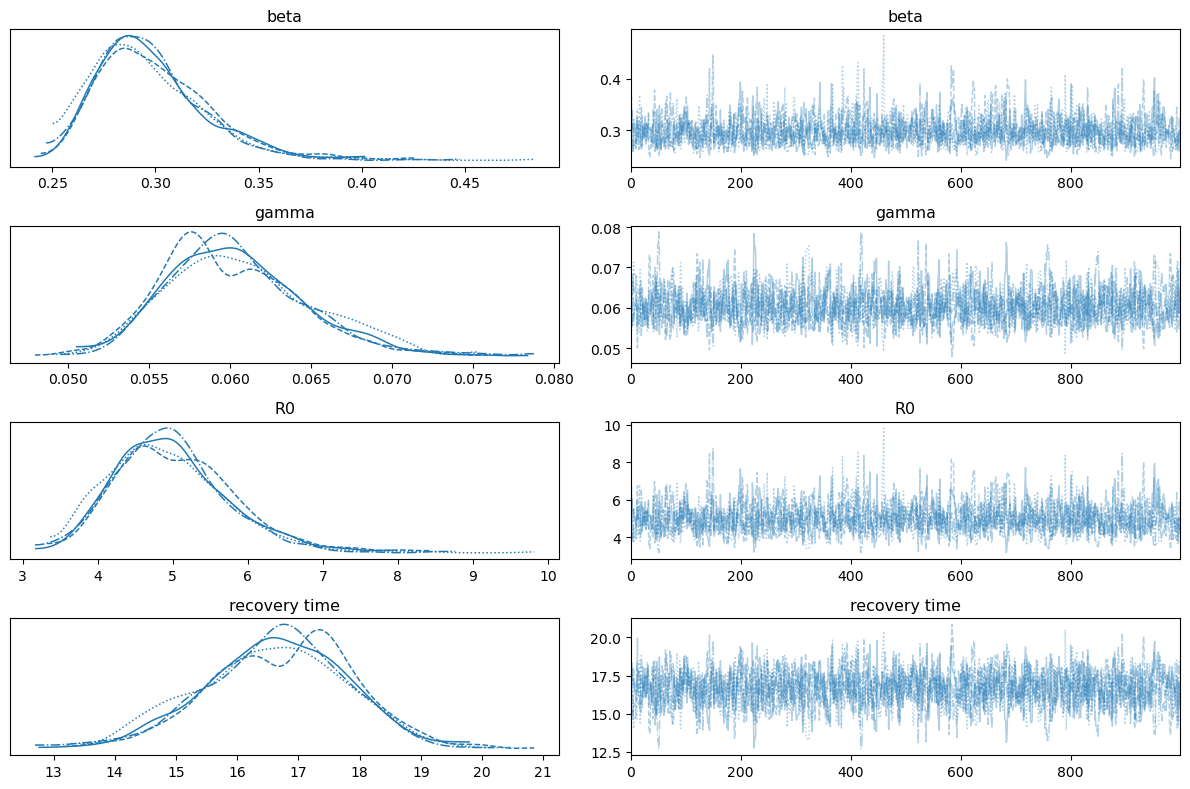

In [52]:
# Trace plots with chains separate
az.plot_trace(
    idata_log,
    var_names=["beta", "gamma", "R0", "recovery time"],
    #figsize=(10, 8),
    combined=False  # ensures chains are shown separately and colored
)
plt.tight_layout()
plt.show()


<Axes: >

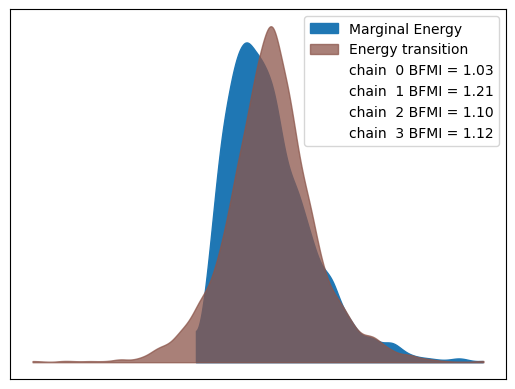

In [53]:
az.plot_energy(idata_log)

<Axes: title={'center': 'beta'}>

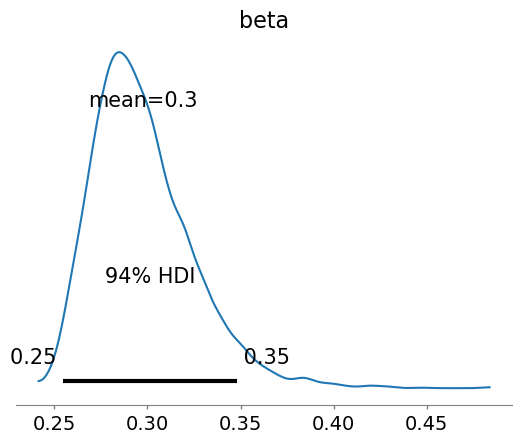

In [54]:
az.plot_posterior(idata_log, var_names=["beta"])

<Axes: title={'center': 'gamma'}>

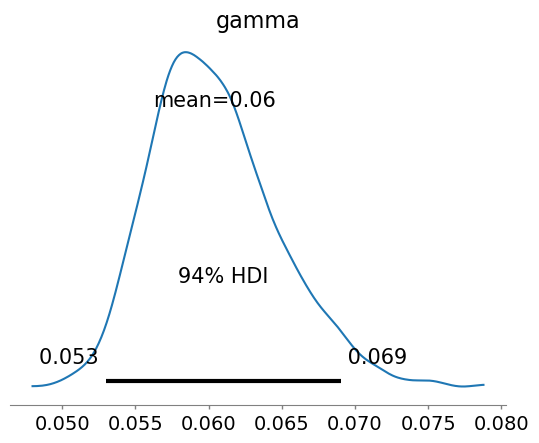

In [55]:
az.plot_posterior(idata_log, var_names=["gamma"])

<Axes: title={'center': 'R0'}>

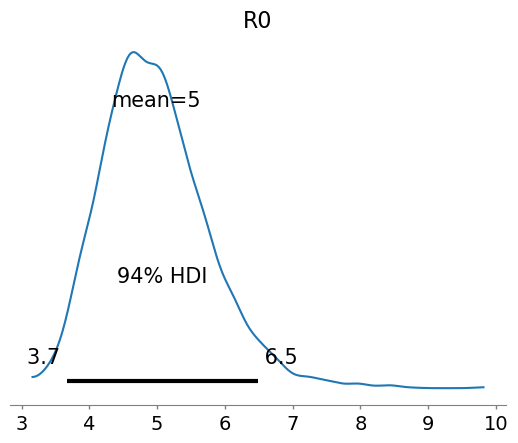

In [56]:
az.plot_posterior(idata_log, var_names=["R0"])

<Axes: title={'center': 'recovery time'}>

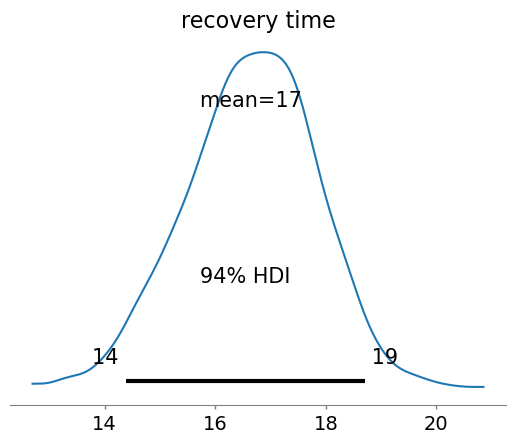

In [57]:
az.plot_posterior(idata_log, var_names=["recovery time"])

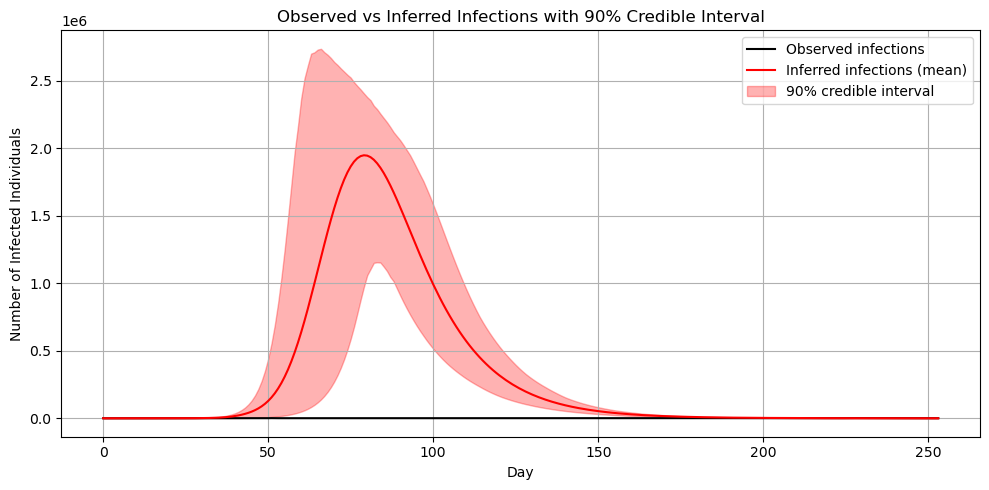

In [63]:
# ----------------------------------------
# 1. Extract posterior samples of I_t
# ----------------------------------------

# Thin to reduce memory load if needed
idata_thin = idata_log.sel(draw=slice(None, None, 10))  # Optional: use if large memory use

# Stack samples across chains and draws
I_t_samples = idata_thin.posterior["I_t"].stack(sample=("chain", "draw")).values  # shape: [time, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# If you have the original observed data in a variable like `infected`:
days = np.arange(len(I_t_mean))  # or use actual time values if available

plt.figure(figsize=(10, 5))
plt.plot(days, infected, '-', label="Observed infections", color='black')
plt.plot(days, I_t_mean, label="Inferred infections (mean)", color='red')
plt.fill_between(days, I_t_lower, I_t_upper, color='red', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Infected Individuals")
plt.title("Observed vs Inferred Infections with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag_out.png')
plt.show()

In [60]:
waic = az.waic(idata_log)
waic

Computed from 4000 posterior samples and 254 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1917.13    21.53
p_waic        2.53        -

In [61]:
loo = az.loo(idata_log)
loo

Computed from 4000 posterior samples and 254 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1917.14    21.53
p_loo        2.53        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      254  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

### Specify model time window as subset of full dataset 

In [26]:
infected=df1.I[:90]
#infected = infected.reset_index(drop=True)

n_days = len(infected)
times = np.arange(n_days)
t_0 = 0
I_begin = infected.iloc[0]
S_begin = N - infected.iloc[0]
new_I0 = pt.zeros_like(I_begin)
#creates a tensor filled with zeros that has the same shape and data type as x

In [27]:
df1.I[:90].sum()

24898.0

In [28]:
infected

Date
02/03/2020     1.0
03/03/2020     1.0
04/03/2020     3.0
05/03/2020     3.0
06/03/2020     5.0
              ... 
26/05/2020    68.0
27/05/2020    41.0
28/05/2020    37.0
29/05/2020    55.0
30/05/2020    66.0
Name: I, Length: 90, dtype: float64

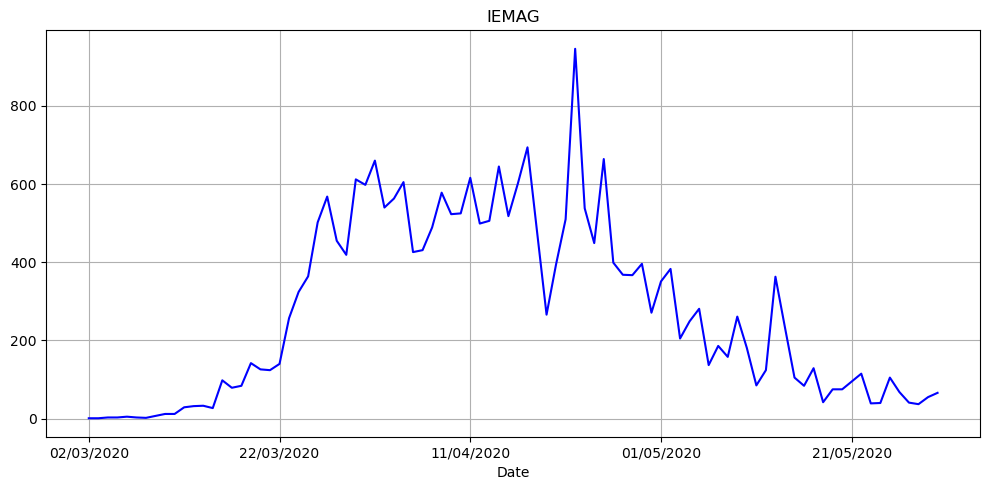

In [34]:
infected.plot(figsize=(10, 5), title=dataset,color='blue')
plt.grid(True)
plt.tight_layout()
plt.savefig('IEMAG1.png')
plt.show()


In [30]:
sum(infected<0)

0

## Define the model 

__si_func__ describes the ODE for the SIR model\
Marginalised estimate, ignoring R(t), which is not available, and calculating S(t) as N minus I(t)\
This function is based on: https://github.com/Priesemann-Group/covid19_inference/blob/master/covid19_inference/model/compartmental_models/SIR.py


In [31]:
def si_func(S_t, I_t, new_I0, beta, gamma, N):
    
    new_I_t = beta * S_t * I_t / N
    new_R_t = gamma * I_t 
    
    S_t = S_t - new_I_t 
    
    I_t = I_t + new_I_t - new_R_t   
    I_t = pt.clip(I_t, -1, N)  # for stability
    
    S_t = pt.clip(S_t, 0, N)
    
    return S_t, I_t, new_I_t


## Run the simulation using PyMC

* Priors: assumed distributions and their parameters for the beta and gamma
* Taken from Semenova et al. (2020) paper at https://mc-stan.org/learn-stan/case-studies/boarding_school_case_study.html
* Their code in Rstats and STAN at https://github.com/charlesm93/disease_transmission_workflow/blob/main/full_case_study_final.Rmd
  
* __pt.zeros__ Variables, S, I and R are initialised as tensors with zero values for the model variables
* __pt.subtensor.inc_subtensor__ PyTensor expression used to initialize the values of the first element of tensors S and I (for Susceptible and Infected)

* __scan__ Like in TensorFlow, we have initiated a graph, this then iterates through the ODE as defined in __si_func__



PyMC runs the Markov Chain Monte Carlo (MCMC), by default this is the No U-Turns (NUTS) algorithm 

In [32]:
with pm.Model() as mod2:
    
    # Priors
    beta = pm.Wald('beta', 1, 1)
    gamma = pm.Wald('gamma', 1, 1)
    
    # Variables
    S = pt.zeros(n_days)
    I = pt.zeros(n_days)
    R = pt.zeros(n_days)
    
    S = pt.subtensor.inc_subtensor(S[0], N - infected.iloc[0])
    I = pt.subtensor.inc_subtensor(I[0], infected.iloc[0])
    
    outputs, _ = scan(
        fn=si_func,
        outputs_info=[S_begin, I_begin, new_I0],
        non_sequences=[beta, gamma, N],
        n_steps=n_days
    )
    S_t, I_t, new_I_t = outputs
    
    S_t = pm.Deterministic("S_t", S_t)
    I_t = pm.Deterministic("I_t", I_t)
    #R_t = pm.Deterministic("R_t", R_t)
        
    # Likelihood
    phi_inv = pm.Exponential("phi_inv", 5)
    y=pm.NegativeBinomial("y", mu=I_t, alpha=phi_inv, observed=infected)
    
    R0 = pm.Deterministic("R0", beta/gamma)
    recovery_time = pm.Deterministic("recovery time", 1/gamma)
    
with mod:
    idata_log2 = pm.sample(1000, idata_kwargs={"log_likelihood": True},chains=4)
    idata_log2.extend(pm.sample_posterior_predictive(idata))
    #idata = pm.sample_prior_predictive(draws=50)

summ = az.summary(idata_log2, hdi_prob=0.9)

# Get current time formatted as yyyy-mm-dd hh:mm:ss
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(current_time)


NotImplementedError: Cannot convert None to a tensor variable.

In [ ]:
pm.model_to_graphviz(mod2)

* Chain is one sequence of samples, by default 4 are run, but this can be changed manually above 
* Divergences suggest that the sampler had trouble traversing parts of the parameter space smoothly

In [ ]:
az.summary(idata_log2, var_names=["beta", "gamma", "R0", "recovery time"],hdi_prob=0.9)

In [ ]:
idata_log2

In [ ]:
# Trace plots with chains separate
az.plot_trace(
    idata_log2,
    var_names=["beta", "gamma", "R0", "recovery time"],
    #figsize=(10, 8),
    combined=False  # ensures chains are shown separately and colored
)
plt.tight_layout()
plt.show()


In [ ]:
az.plot_energy(idata_log2)

In [ ]:
az.plot_posterior(idata_log2, var_names=["beta"])

In [ ]:
az.plot_posterior(idata_log2, var_names=["gamma"])

In [ ]:
az.plot_posterior(idata_log2, var_names=["R0"])

In [ ]:
az.plot_posterior(idata_log2, var_names=["recovery time"])

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t
# ----------------------------------------

# Thin to reduce memory load if needed
idata_thin = idata_log2.sel(draw=slice(None, None, 10))  # Optional: use if large memory use

# Stack samples across chains and draws
I_t_samples = idata_thin.posterior["I_t"].stack(sample=("chain", "draw")).values  # shape: [time, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# If you have the original observed data in a variable like `infected`:
days = np.arange(len(I_t_mean))  # or use actual time values if available

plt.figure(figsize=(10, 5))
plt.plot(days, infected, '-', label="Observed infections", color='black')
plt.plot(days, I_t_mean, label="Inferred infections (mean)", color='red')
plt.fill_between(days, I_t_lower, I_t_upper, color='red', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Infected Individuals")
plt.title("Observed vs Inferred Infections with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
waic = az.waic(idata_log2)
waic

In [ ]:
loo = az.loo(idata_log2)
loo

In [ ]:
idata_log2